In [11]:
%pip install -q torch torchaudio librosa matplotlib intervaltree h5py numpy ipywidgets soundfile torchcodec ray silero-vad

## Prepare Data

In [12]:
from pathlib import Path

RESPIRO_DIR = Path("respiro-en")

SKIP_DOWNLOAD = False          # ← set True if you already have the data
DATA_DIR      = Path("data")

LIBRI_T_ROOT    = DATA_DIR / "LibriTTS-R"
ARCHIVE_T_PATH  = DATA_DIR / "test_clean.tar.gz"
DOWNLOAD_T_URL  = "https://openslr.trmal.net/resources/141/test_clean.tar.gz"


SPLIT_DIR = LIBRI_T_ROOT / "LibriTTS_R" / "test-clean"
wav_files = sorted(SPLIT_DIR.rglob("*.wav"))

In [13]:
from utils import download

DATA_DIR.mkdir(exist_ok=True)

if not SKIP_DOWNLOAD:
    download(DOWNLOAD_T_URL, ARCHIVE_T_PATH, LIBRI_T_ROOT, "test_clean")
else:
    print(f"Skipping download. Using existing data at {LIBRI__T_ROOT}")

Archive already present, skipping download.
Extracting archive (this may take a few minutes) ...


/tmp/ipykernel_2792/2218289209.py:27: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(output_dir)


Extraction complete.


In [ ]:
import pandas as pd
from intervaltree import IntervalTree
import ast

from eval import evaluate_dataset


test_set = pd.read_csv("respiro-en/datasets/test-clean.csv")

split_path = test_set['path'].str.split('_', expand=True)
test_set['Audio_filepath'] = str(SPLIT_DIR) + '/'+ split_path[0] + '/' +\
 split_path[1] + '/' + test_set['path'] + '.wav'

test_set['breath'] = test_set['breath'].apply(ast.literal_eval)

test_set_paths = test_set['Audio_filepath']

ground_truths = test_set['breath'].to_numpy()
ground_truths = [IntervalTree.from_tuples(x) for x in ground_truths]
len(ground_truths)

In [ ]:
### LOAD MODEL REPO ############
import os
import sys


if not RESPIRO_DIR.exists():
    !git clone --depth 1 https://github.com/ydqmkkx/Respiro-en respiro-en
else:
    print("Respiro-en already cloned.")

# Add to Python path so we can import modules.py
sys.path.insert(0, str(RESPIRO_DIR))
print("Files in respiro-en:", [f.name for f in RESPIRO_DIR.iterdir()])


## Load Models

In [14]:
import torch
from modules import DetectionNet, BreathDetector   # from respiro-en/modules.py
from silero_vad import load_silero_vad, read_audio, get_speech_timestamps
from models import TwoStageBreathDetector, DetectorWrapper, preprocess_respiro


#### LOAD MODEL ###############
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

MODEL_PATH = RESPIRO_DIR / "respiro-en.pt"

model_vad = load_silero_vad()
stage_1st = lambda x: get_speech_timestamps(
  x,
  model_vad,
  return_seconds=True,
)

model = DetectionNet().to(DEVICE)
ckpt  = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()

detector_custom = DetectorWrapper(model)

two_stage = TwoStageBreathDetector(detector_custom, preprocess_respiro,
                                   stage_1st, read_audio, detector.postprocess)

respiro = BreathDetector(model)


Respiro-en already cloned.
Files in respiro-en: ['demo.ipynb', '.git', 'LICENSE', 'README.md', 'datasets', 'model.png', 'samples', 'modules.py', 'respiro-en.pt', '__pycache__']
Using device: cpu
Model loaded successfully.


## Quantitative Eval

In [ ]:
from tqdm import tqdm

conformer_preds = []
two_stage_preds = []
for _, path in tqdm(enumerate(test_set_paths, 0),
                    total=len(test_set_paths)):
  conformer_preds.append(respiro(path))
  two_stage_preds.append(two_stage(path))

In [280]:
conformer_res = evaluate_dataset(conformer_preds, ground_truths)
conformer_res

Metrics(precision=0.9485981308411215, recall=0.8458333333333333, f1=0.894273127753304, mean_iou=np.float64(0.9369642779742344), tp=406, fp=22, fn=74)

In [281]:
two_stage_res = evaluate_dataset(two_stage_preds, ground_truths)
two_stage_res

Metrics(precision=0.65, recall=0.40625, f1=0.5000000000000001, mean_iou=np.float64(0.8362854410970002), tp=195, fp=105, fn=285)

## Exploratory Qualitative Eval

data/LibriTTS-R/LibriTTS_R/test-clean/7176/88083/7176_88083_000011_000005.wav
tensor([1.2365e-09, 2.2997e-09, 7.4967e-10,  ..., 8.1778e-03, 7.5012e-03,
        6.8732e-03])


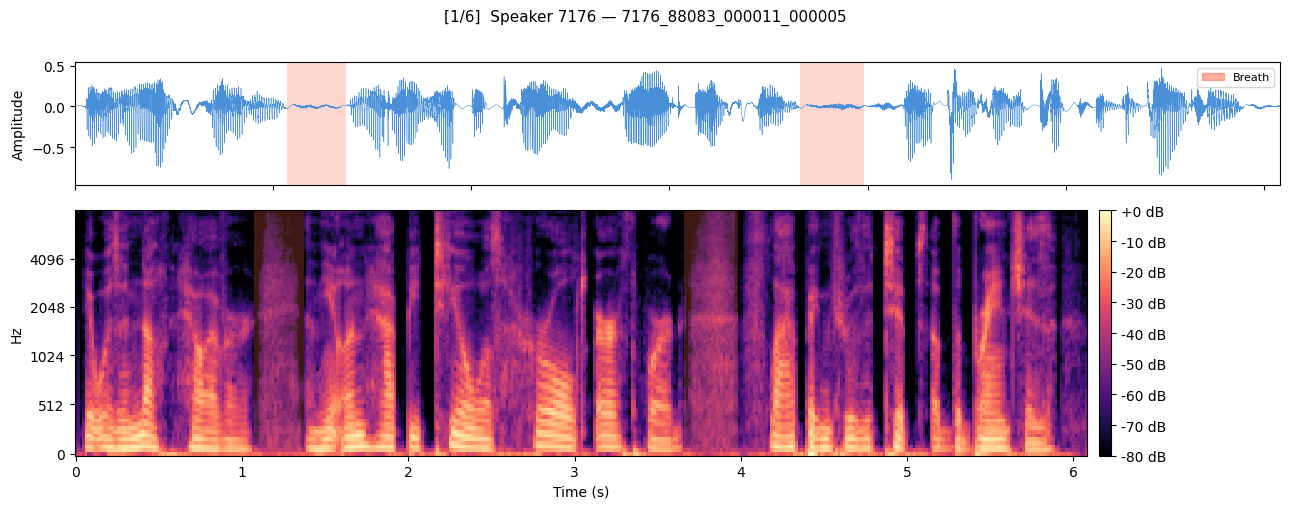

  Duration: 6.08s  |  Breaths detected: 2  |  Total breath time: 0.62s (10.2%)
  Intervals (s): [(np.float64(1.07), np.float64(1.37)), (np.float64(3.66), np.float64(3.98))]



data/LibriTTS-R/LibriTTS_R/test-clean/2300/131720/2300_131720_000016_000008.wav
tensor([ 5.5565e-12, -3.2928e-10, -2.9927e-11,  ...,  6.9492e-04,
         8.7931e-04,  9.8184e-04])


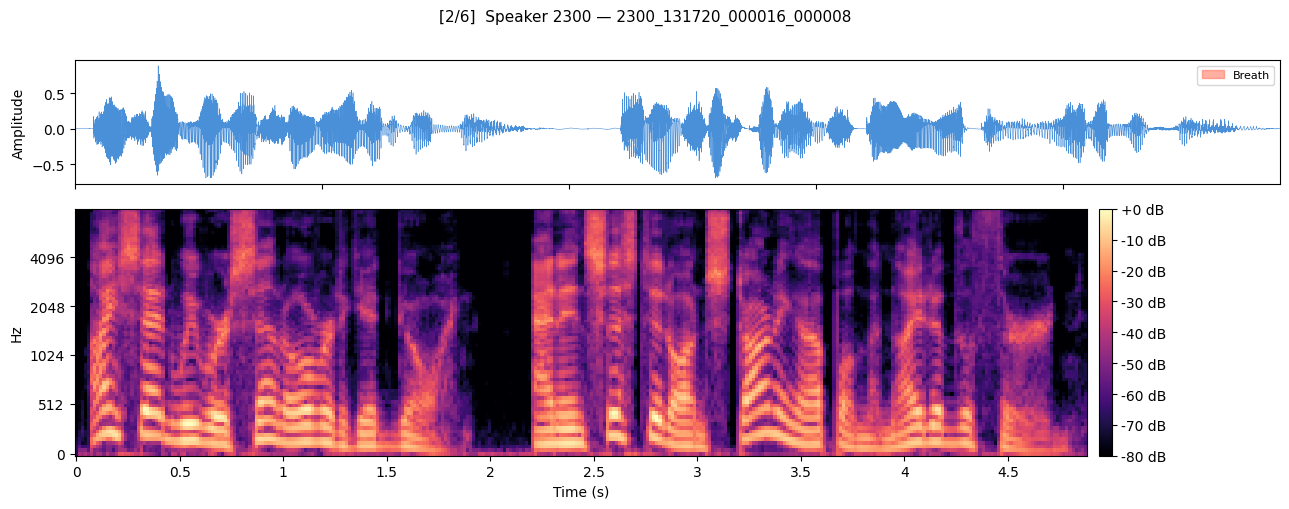

  Duration: 4.88s  |  Breaths detected: 0  |  Total breath time: 0.00s (0.0%)



data/LibriTTS-R/LibriTTS_R/test-clean/8230/279154/8230_279154_000024_000003.wav
tensor([ 5.8728e-10, -5.9354e-11,  2.8249e-10,  ...,  2.8700e-02,
         9.4634e-02, -5.4238e-03])


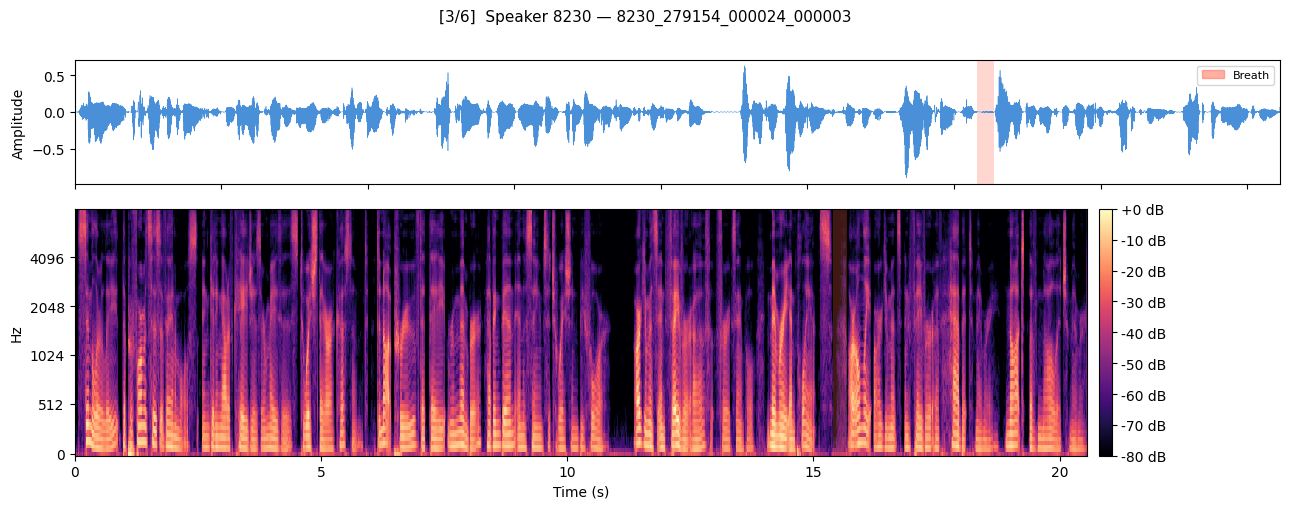

  Duration: 20.56s  |  Breaths detected: 1  |  Total breath time: 0.28s (1.4%)
  Intervals (s): [(np.float64(15.4), np.float64(15.68))]



data/LibriTTS-R/LibriTTS_R/test-clean/260/123286/260_123286_000032_000002.wav
tensor([ 9.1865e-11,  1.6668e-09,  2.4314e-09,  ..., -1.9407e-01,
        -6.4151e-01,  3.8708e-02])


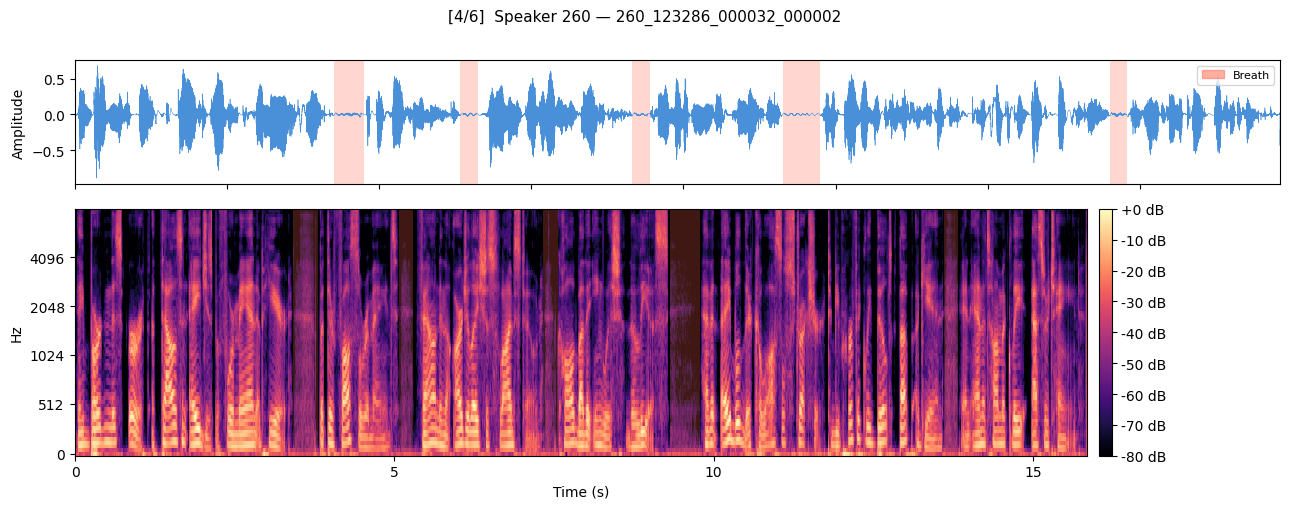

  Duration: 15.84s  |  Breaths detected: 5  |  Total breath time: 1.57s (9.9%)
  Intervals (s): [(np.float64(3.41), np.float64(3.81)), (np.float64(5.07), np.float64(5.3)), (np.float64(7.33), np.float64(7.56)), (np.float64(9.31), np.float64(9.79)), (np.float64(13.6), np.float64(13.83))]



data/LibriTTS-R/LibriTTS_R/test-clean/6829/68769/6829_68769_000017_000002.wav
tensor([ 2.5644e-11,  5.8053e-11,  7.0678e-10,  ..., -7.1790e-03,
        -7.2687e-03, -7.6506e-03])


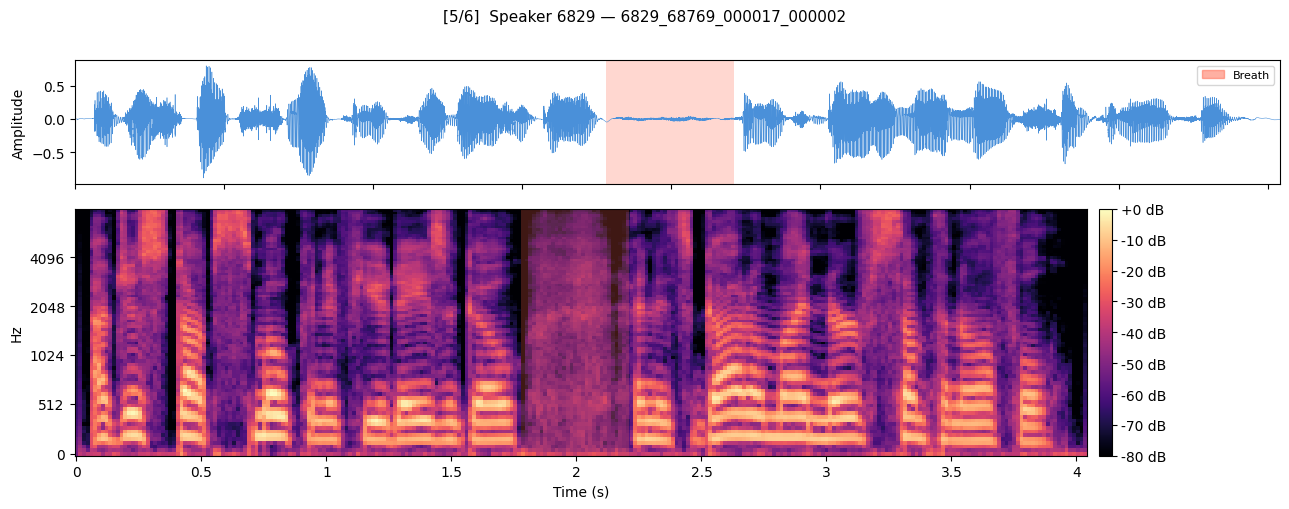

  Duration: 4.04s  |  Breaths detected: 1  |  Total breath time: 0.43s (10.6%)
  Intervals (s): [(np.float64(1.78), np.float64(2.21))]



data/LibriTTS-R/LibriTTS_R/test-clean/8224/274384/8224_274384_000037_000000.wav
tensor([ 9.3075e-10,  4.4404e-10,  2.1851e-10,  ..., -1.1690e-01,
        -3.8685e-01,  2.3440e-02])


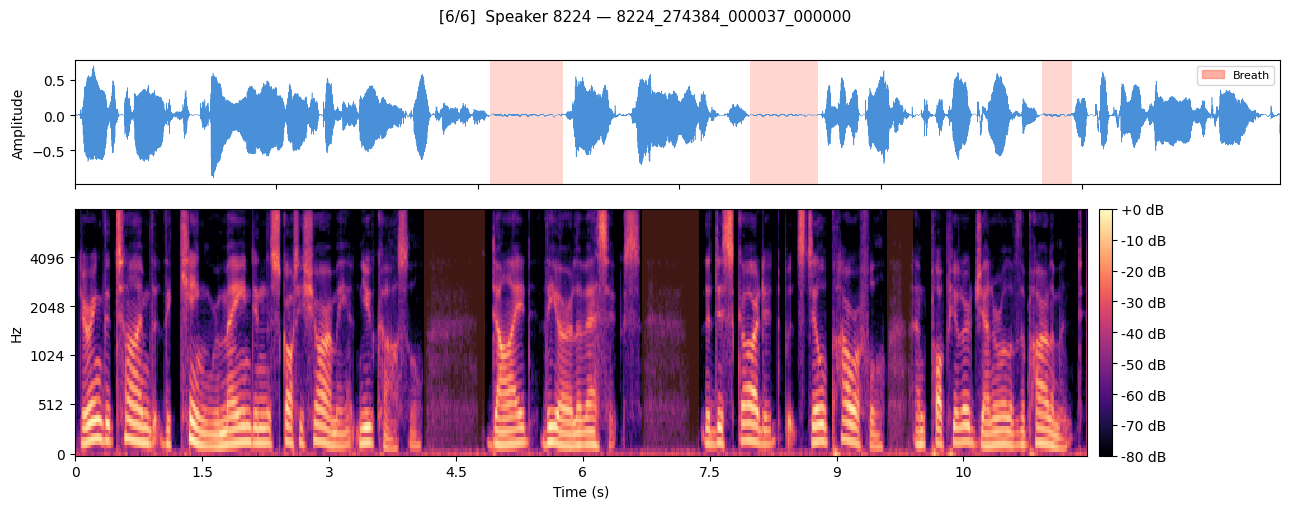

  Duration: 11.96s  |  Breaths detected: 3  |  Total breath time: 1.71s (14.3%)
  Intervals (s): [(np.float64(4.12), np.float64(4.85)), (np.float64(6.7), np.float64(7.38)), (np.float64(9.6), np.float64(9.9))]


In [284]:
import random
from utils import load_audio, plot_segment
import soundfile as sf

random.seed(42)

# Duration distribution over a 2000-utterance sample
sample_files = random.sample(wav_files, min(2000, len(wav_files)))
durations = []
for p in sample_files:
    info = sf.info(str(p))
    durations.append(info.frames / info.samplerate)

# Sample N_SHOW random utterances and visualise them
N_SHOW = 6

# Filter to utterances >= 4 s for interesting content
candidates = [
    p for p in sample_files
    if sf.info(str(p)).frames / sf.info(str(p)).samplerate >= 4.0
]
show_files = random.sample(candidates, min(N_SHOW, len(candidates)))

for i, path in enumerate(show_files):
    spk = path.parts[-3]
    print(path)
    breath_preds = respiro(path)
    wave, sr = load_audio(str(path))
    plot_segment(breath_preds, wave, sr, title=f"[{i+1}/{N_SHOW}]  Speaker {spk} — {path.stem}")

In [283]:
from importlib import reload
import utils
reload(utils)

<module 'utils' from '/content/utils.py'>

data/LibriTTS-R/LibriTTS_R/test-clean/7176/88083/7176_88083_000011_000005.wav
tensor([1.2365e-09, 2.2997e-09, 7.4967e-10,  ..., 8.1778e-03, 7.5012e-03,
        6.8732e-03])


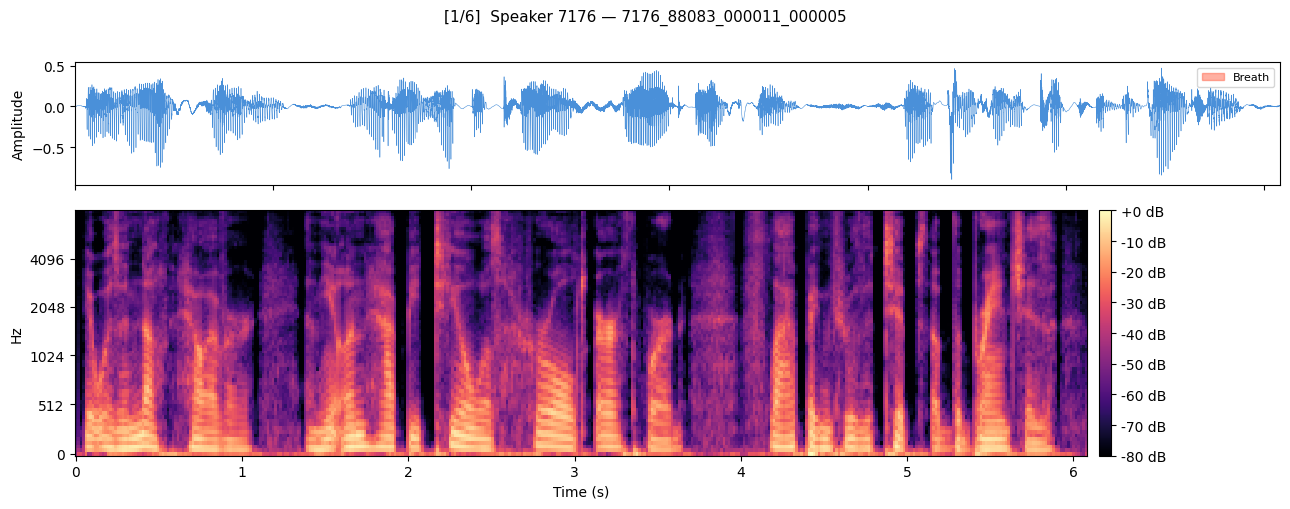

  Duration: 6.08s  |  Breaths detected: 0  |  Total breath time: 0.00s (0.0%)



data/LibriTTS-R/LibriTTS_R/test-clean/2300/131720/2300_131720_000016_000008.wav
tensor([ 5.5565e-12, -3.2928e-10, -2.9927e-11,  ...,  6.9492e-04,
         8.7931e-04,  9.8184e-04])


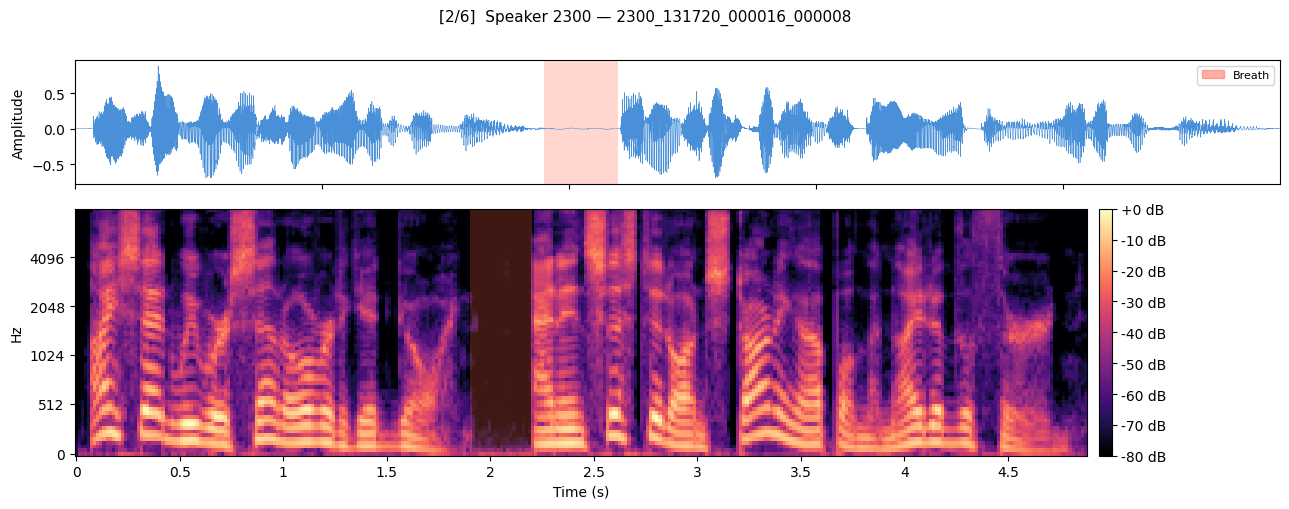

  Duration: 4.88s  |  Breaths detected: 1  |  Total breath time: 0.30s (6.1%)
  Intervals (s): [(np.float64(1.9), np.float64(2.2))]



data/LibriTTS-R/LibriTTS_R/test-clean/8230/279154/8230_279154_000024_000003.wav
tensor([ 5.8728e-10, -5.9354e-11,  2.8249e-10,  ...,  2.8700e-02,
         9.4634e-02, -5.4238e-03])


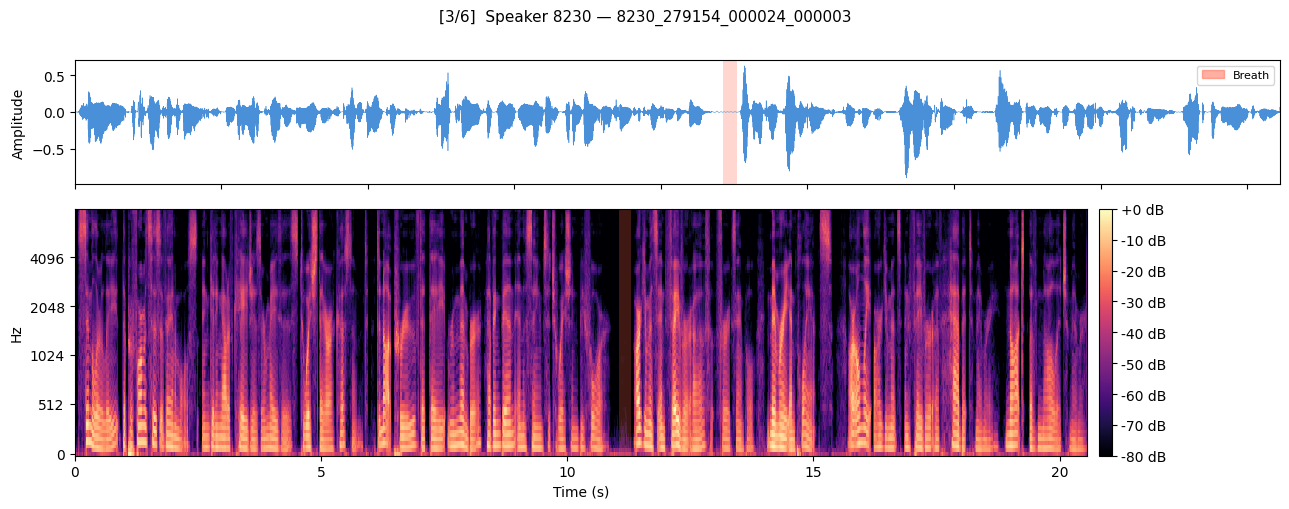

  Duration: 20.56s  |  Breaths detected: 1  |  Total breath time: 0.24s (1.2%)
  Intervals (s): [(np.float64(11.06), np.float64(11.3))]



data/LibriTTS-R/LibriTTS_R/test-clean/260/123286/260_123286_000032_000002.wav
tensor([ 9.1865e-11,  1.6668e-09,  2.4314e-09,  ..., -1.9407e-01,
        -6.4151e-01,  3.8708e-02])


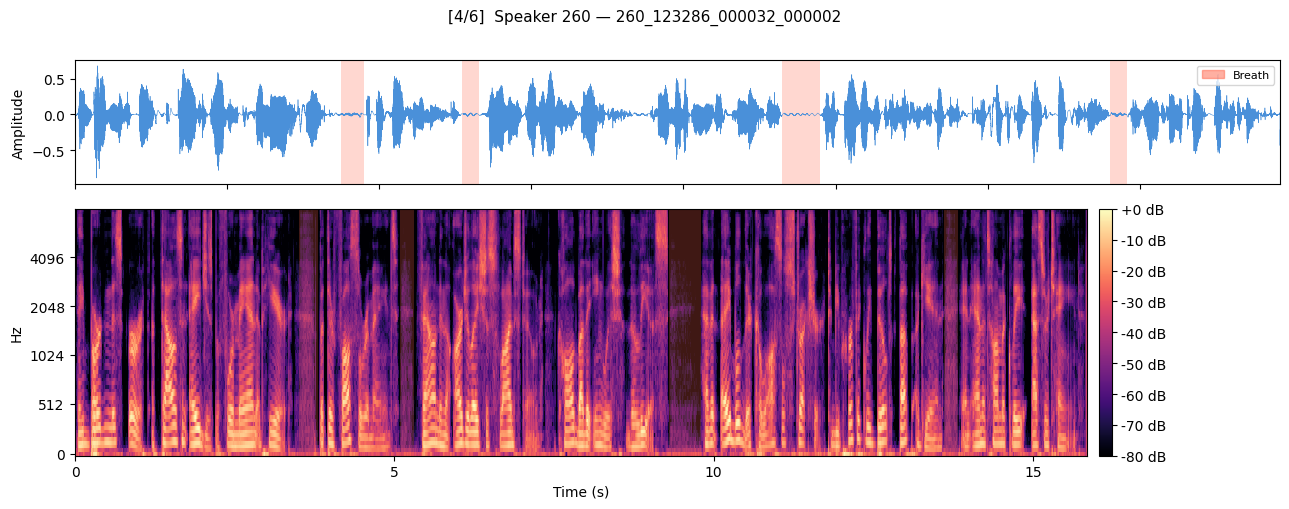

  Duration: 15.84s  |  Breaths detected: 4  |  Total breath time: 1.25s (7.9%)
  Intervals (s): [(np.float64(3.5), np.float64(3.81)), (np.float64(5.09), np.float64(5.31)), (np.float64(9.3), np.float64(9.8)), (np.float64(13.61), np.float64(13.83))]



data/LibriTTS-R/LibriTTS_R/test-clean/6829/68769/6829_68769_000017_000002.wav
tensor([ 2.5644e-11,  5.8053e-11,  7.0678e-10,  ..., -7.1790e-03,
        -7.2687e-03, -7.6506e-03])


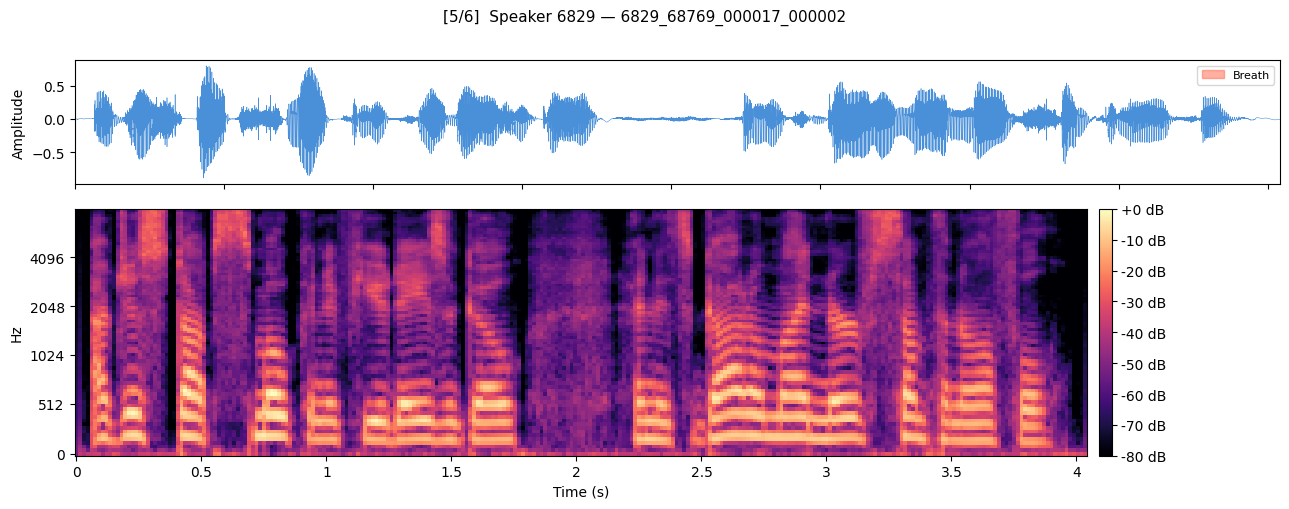

  Duration: 4.04s  |  Breaths detected: 0  |  Total breath time: 0.00s (0.0%)



data/LibriTTS-R/LibriTTS_R/test-clean/8224/274384/8224_274384_000037_000000.wav
tensor([ 9.3075e-10,  4.4404e-10,  2.1851e-10,  ..., -1.1690e-01,
        -3.8685e-01,  2.3440e-02])


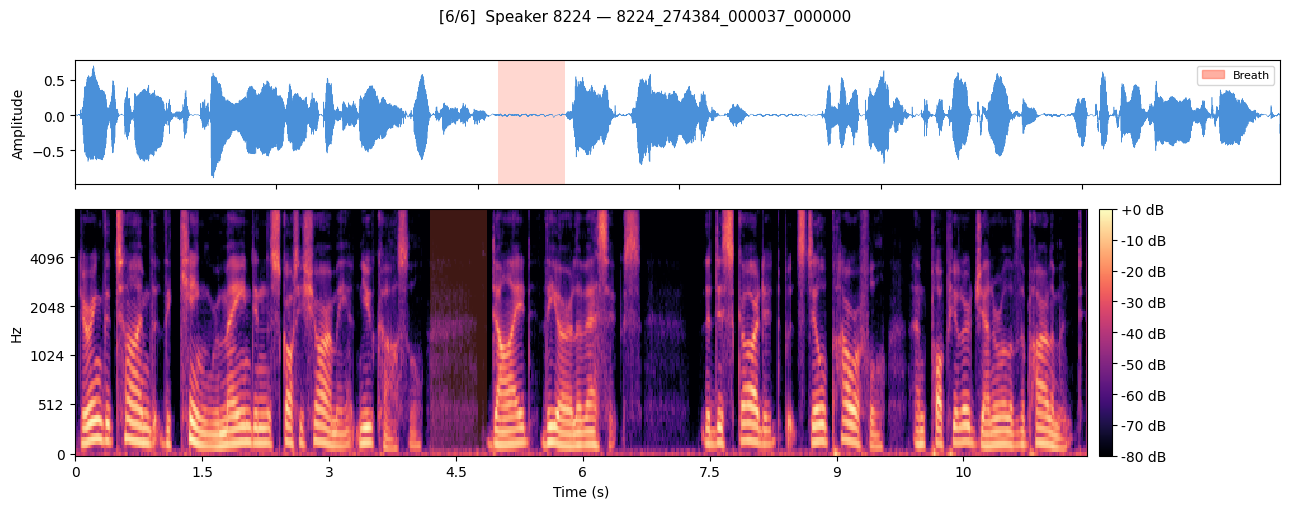

  Duration: 11.96s  |  Breaths detected: 1  |  Total breath time: 0.67s (5.6%)
  Intervals (s): [(np.float64(4.2), np.float64(4.87))]


In [286]:
import random
from utils import load_audio, plot_segment

random.seed(42)

for i, path in enumerate(show_files):
    spk = path.parts[-3]
    print(path)
    breath_preds = two_stage(path)
    wave, sr = load_audio(str(path))
    plot_segment(breath_preds, wave, sr, title=f"[{i+1}/{N_SHOW}]  Speaker {spk} — {path.stem}")